# **Homework 7**  - Language models

## Part 1. Implement a minimal GPT model (35 pts).

Implementation:
Decoder-only Transformer language model high-level structure:

Token Embedding + Positional Embedding → Transformer Blocks×L → Linear LM Head.

Each Transformer block should include:
- masked multi-head self-attention,
- a feed-forward MLP,
- residual connections,
- layer normalization.

Separate components for:
- self-attention,
- a Transformer block,
- the full GPT model.

In [1]:
import math
import inspect
import matplotlib.pyplot as plt
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F



## Component 1: Self-Attention

In [16]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd)
        self.out_proj = nn.Linear(n_embd, n_embd)

        # regularization
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        self.register_buffer(
            "causal_mask", # Added name string
            torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        )

    def forward(self, x):
        B, T, C = x.shape # B = batch size; T = sequence length; C = embedding dimension / channels

        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        # calculate query, key, values for all heads in batch
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        attn_scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        attn_scores = attn_scores.masked_fill(
            self.causal_mask[:, :, :T, :T] == 0,
            float("-inf")
        )

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        y = attn_weights @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)

        y = self.out_proj(y)
        y = self.resid_dropout(y)

        return y

## Component 2: Transformer Block

### Feed-forward MLP

In [17]:
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [18]:
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)

        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## Component 3: GPT Language Model

In [19]:
class GPTLangModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd=128,
        n_head=4,
        n_layer=4,
        dropout=0.1
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_embd, n_head, block_size, dropout)
                for _ in range(n_layer)
            ]
        )

        self.ln_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape    #idx is the raw input token IDs

        assert T <= self.block_size #check Sequence length larger than block size

        token_emb = self.token_embedding(idx)

        positions = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(positions)

        x = token_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_final(x)

        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

## Model Evaluation

In [20]:
@torch.no_grad()
def generate(model, idx, max_new_tokens):
    model.eval()

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]

        logits, _ = model(idx_cond)

        logits = logits[:, -1, :]

        probs = F.softmax(logits, dim=-1)

        next_idx = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_idx), dim=1)

    return idx

In [21]:
vocab_size = 65
block_size = 128

model = GPTLangModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.1
)

x = torch.randint(0, vocab_size, (4, block_size))
y = torch.randint(0, vocab_size, (4, block_size))

logits, loss = model(x, y)

print("Logits shape:", logits.shape)
print("Loss:", loss.item())

Logits shape: torch.Size([4, 128, 65])
Loss: 4.325020790100098


## Part 1: Short notes on architecture choice

For this assignment, I implemented a minimal decoder-only GPT-style Transformer language model in PyTorch. The model consists of token embeddings, learned positional embeddings, a stack of Transformer blocks, a final layer normalization, and a linear language modeling head.

Each Transformer block uses masked multi-head self-attention, a feed-forward MLP, residual connections, and layer normalization. The causal mask ensures that each token can only attend to previous tokens and itself, which makes the model suitable for autoregressive next-token prediction.

Architecture choices:
- Number of Transformer layers: 4
- Number of attention heads: 4
- Embedding dimension: 128
- Context length / block size: 128 tokens
- Dropout: 0.1
- MLP hidden size: 4 × embedding dimension

# Part 2. Implement the training pipeline (30 pts)

Recreate the core training logic of a small autoregressive language model. Your training
pipeline should include:
- forming input/target token sequences for next-token prediction,
- minibatch sampling from a text corpus,
- a training loop with optimizer updates,
- periodic evaluation on a validation split,
- logging of training and validation loss over time.
                                 
Use any reasonable optimizer and hyperparameters (for example, AdamW).
Deliverables.
- Training code.
- A plot of training and validation loss versus iteration or epoch.

In [22]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


### Load test data - German language dataset - Kafka’s Die Verwandlung

In [23]:
!wget -O german_kafka.txt https://www.gutenberg.org/cache/epub/22367/pg22367.txt

--2026-04-27 00:32:11--  https://www.gutenberg.org/cache/epub/22367/pg22367.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 145986 (143K) [text/plain]
Saving to: ‘german_kafka.txt’

german_kafka.txt    100%[===================>] 142.56K   225KB/s    in 0.6s    

2026-04-27 00:32:13 (225 KB/s) - ‘german_kafka.txt’ saved [145986/145986]



In [24]:
with open("german_kafka.txt", "r", encoding="utf-8-sig") as f:
    raw_text = f.read()

print(raw_text[:1000])
print("Raw length:", len(raw_text))

The Project Gutenberg eBook of Die Verwandlung
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Die Verwandlung

Author: Franz Kafka


        
Release date: August 21, 2007 [eBook #22367]
                Most recently updated: December 29, 2017

Language: German

Other information and formats: www.gutenberg.org/ebooks/22367

Credits: Produced by Jana Srna, Alexander Bauer and the Online
        Distributed Proofreading Team at http://www.pgdp.net


*** START OF THE PROJECT GUTENBERG EBOOK DIE VERWANDLUNG ***




Produced by Jana Srna, Alexander Bauer and the Online
Distributed Proofrea

### Data Cleaning - to remove headers and footers

In [25]:
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK DIE VERWANDLUNG ***"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK DIE VERWANDLUNG ***"

start = raw_text.find(start_marker)
end = raw_text.find(end_marker)

if start != -1:
    raw_text = raw_text[start + len(start_marker):]

if end != -1:
    raw_text = raw_text[:end]

text = raw_text.strip()

print("Cleaned length:", len(text))
print(text[:1000])

Cleaned length: 122582
Produced by Jana Srna, Alexander Bauer and the Online
Distributed Proofreading Team at http://www.pgdp.net






                          DIE VERWANDLUNG

                                VON

                            FRANZ KAFKA


                  K U R T  W O L F F  V E R L A G

                           L E I P Z I G




 B Ü C H E R E I  »D E R  J Ü N G S T E  T A G«  B A N D  2 2 / 2 3

              GEDRUCKT BEI DIETSCH & BRÜCKNER · WEIMAR




            COPYRIGHT KURT WOLFF VERLAG · LEIPZIG. 1917




I.


Als Gregor Samsa eines Morgens aus unruhigen Träumen erwachte, fand er
sich in seinem Bett zu einem ungeheueren Ungeziefer verwandelt. Er lag
auf seinem panzerartig harten Rücken und sah, wenn er den Kopf ein wenig
hob, seinen gewölbten, braunen, von bogenförmigen Versteifungen
geteilten Bauch, auf dessen Höhe sich die Bettdecke, zum gänzlichen
Niedergleiten bereit, kaum noch erhalten konnte. Seine vielen, im
Vergleich zu seinem sonstigen Umfang klä

### Data Cleaning for German special characters like ä, ö, ü, ß, and quotation marks

In [26]:
import re

text = text.replace("\r\n", "\n")
text = text.replace("\r", "\n")

text = re.sub(r"\n{3,}", "\n\n", text)
text = re.sub(r"[ \t]+", " ", text)

text = text.strip()

print("Final cleaned length:", len(text))
print(text[:1000])

Final cleaned length: 122398
Produced by Jana Srna, Alexander Bauer and the Online
Distributed Proofreading Team at http://www.pgdp.net

 DIE VERWANDLUNG

 VON

 FRANZ KAFKA

 K U R T  W O L F F  V E R L A G

 L E I P Z I G

 B Ü C H E R E I  »D E R  J Ü N G S T E  T A G«  B A N D  2 2 / 2 3

 GEDRUCKT BEI DIETSCH & BRÜCKNER · WEIMAR

 COPYRIGHT KURT WOLFF VERLAG · LEIPZIG. 1917

I.

Als Gregor Samsa eines Morgens aus unruhigen Träumen erwachte, fand er
sich in seinem Bett zu einem ungeheueren Ungeziefer verwandelt. Er lag
auf seinem panzerartig harten Rücken und sah, wenn er den Kopf ein wenig
hob, seinen gewölbten, braunen, von bogenförmigen Versteifungen
geteilten Bauch, auf dessen Höhe sich die Bettdecke, zum gänzlichen
Niedergleiten bereit, kaum noch erhalten konnte. Seine vielen, im
Vergleich zu seinem sonstigen Umfang kläglich dünnen Beine flimmerten
ihm hilflos vor den Augen.

»Was ist mit mir geschehen?« dachte er. Es war kein Traum. Sein Zimmer,
ein richtiges, nur etwas zu kl

### Tokenizer

In [27]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = { ch:i for i, ch in enumerate(chars) }
itos = { i:ch for i, ch in enumerate(chars) }

def encode(s):
    return [stoi[c] for c in s]

def decode(tokens):
    return "".join([itos[i] for i in tokens])

print("Vocabulary size:", vocab_size)

Vocabulary size: 84


### Text to tensor Conversion and Split

In [28]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Validation tokens:", len(val_data))

Train tokens: 110158
Validation tokens: 12240


### Hyperparameters

In [29]:
batch_size = 32
block_size = 128

max_iters = 2500
eval_interval = 250
eval_iters = 100

learning_rate = 3e-4

n_embd = 128
n_head = 4
n_layer = 3
dropout = 0.2

### Model and Optimizer

In [30]:
model = GPTLangModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

### Minibatch sampling

In [31]:
def get_batch(split):
    data_split = train_data if split == "train" else val_data

    ix = torch.randint(len(data_split) - block_size, (batch_size,))

    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])

    x = x.to(device)
    y = y.to(device)

    return x, y

### Loss evaluation function

In [32]:
@torch.no_grad()
def estimate_loss(model):
    out = {}

    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            xb, yb = get_batch(split)
            logits, loss = model(xb, yb)
            losses[k] = loss.item()

        out[split] = losses.mean().item()

    model.train()

    return out

### Training

In [33]:
train_losses = []
val_losses = []
steps = []

for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss(model)

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps.append(iter)

        print(
            f"step {iter}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.6226, val loss 4.6311
step 250: train loss 2.3864, val loss 2.5296
step 500: train loss 2.2997, val loss 2.4574
step 750: train loss 2.1035, val loss 2.2853
step 1000: train loss 1.8933, val loss 2.1230
step 1250: train loss 1.7601, val loss 1.9970
step 1500: train loss 1.6500, val loss 1.9104
step 1750: train loss 1.5766, val loss 1.8735
step 2000: train loss 1.5054, val loss 1.8250
step 2250: train loss 1.4515, val loss 1.8008
step 2499: train loss 1.4049, val loss 1.7656


### Training and Validation loss Plot

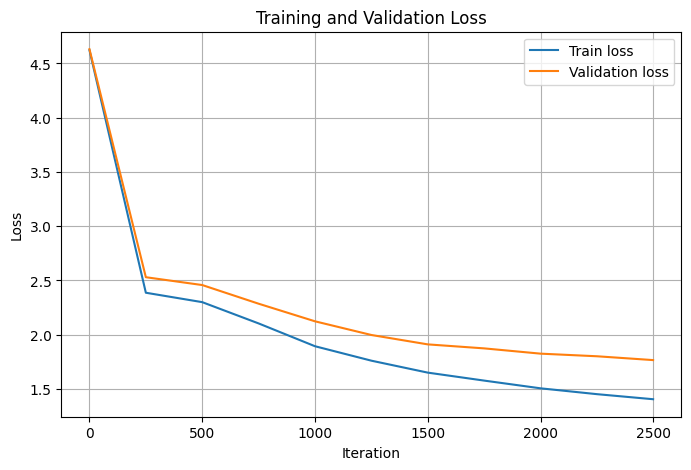

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, label="Train loss")
plt.plot(steps, val_losses, label="Validation loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### PART 2 - Notes on Training

### The training pipeline uses character-level next-token prediction. The raw text is converted into integer token IDs using a simple character vocabulary. The dataset is split into training and validation sets using a 90/10 split.

### For each minibatch, random starting positions are sampled from the text. The input sequence x contains block_size tokens, and the target sequence y is the same text shifted one character forward. This trains the model to predict the next token at every position.

### The model is trained using AdamW. During training, the loss is periodically estimated on both the training and validation splits without gradient updates. These losses are logged and plotted to monitor learning progress.

### The training pipeline above was demonstrated using the German language Franz Kafka’s “Die Verwandlung” from Project Gutenberg corpus. In the next section (PART 3), the trained model from this pipeline is used to qualitatively evaluate generation performance.

# PART 3. Train on a small text dataset and evaluate qualitatively (20 pts).

Choose a small text corpus, such as:
- Tiny Shakespeare,
- a character-level or token-level corpus of your choice,
- a small curated subset of a larger dataset.

Train your model long enough to show that it has learned nontrivial patterns from the
data. Then generate text samples from the trained model.

Deliverables.
- Brief description of the dataset and tokenization choice.
- Training and validation loss curves.
- Several generated samples from the model.
- A short discussion of what affects performance in your setup, such as model size,
context length, training time, or tokenization granularit

### Generated text samples after long training

In [35]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_tokens = generate(
    model,
    context,
    max_new_tokens=500
)

generated_text = decode(generated_tokens[0].tolist())

print(generated_text)


Rahl, und hatte nun ihm einem Besicht, sie zu Bewacklief. KUnd dem Abe
zu sich, daß unter sah gute, sich. Wanderung aber dein Kten die Boder und »ich
seckelandert würderum mal hatte und die Zum war eine Eässen zum grübuten
hinachten war, irdfällich jetzt an zwei ihrer Klappelt, daß er Wohnte beude
unterschlöten das Knapf, en seines Betterhelten würde, öffne ihm ervor außerhälte haffe für
die Schwester im Hänig zu schleiben, Gregor ganz kammenkommen.

Der sein wurde stehen groß rerschnun; sagte e


In [36]:
for i in range(3):
    context = torch.zeros((1, 1), dtype=torch.long, device=device)

    generated_tokens = generate(
        model,
        context,
        max_new_tokens=500
    )

    print(f"\n German text Sample {i+1}\n")
    print(decode(generated_tokens[0].tolist()))


 German text Sample 1


Mutterbeitern und drede er fnühlichkte striefen, daß, sie er mir
und er daß der vorstand detzten Schwester and nur gewohl es und rich
zurückschiel mußten und übrungesufregung würde eiglichen Familie
gehesten klosende Schwergen die Mutthelte, nur mer --- er wenn Mimmer nun
dem nicht des Wort den ERepferten ein vörgeneigen ergungegracht hatten; um
großten Abseiten und ander jetzt manken von lenben Einanden
Kageine --- die Mutter Gregor unter früherer bei ihm ein Sensträußig
drüßen einerklämtlicker

 German text Sample 2


Prokringen hinauschlöser die hatte, doch hiben hielte sein zum
Serklehr denken Lungenblde können eine Wollen Türst. Er gewand,
ball bekrähst die Schwester schon der Schwester ist schorg fest
aufze Stisch vob so sich angemeilide und mit herreitung, daß das Er machtlede
durauften aufs der Beschehen, in einen Moder. Tag ganz sich es
sich. So die Mutter nach verglück alles Lein und das Zugen sich der nicht schloßen
überliche, Einfen sich vom Heil üb

### Text generation from a PROMPT

In [37]:
prompt = "Gregor"
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

generated_tokens = generate(
    model,
    context,
    max_new_tokens=500
)

print(decode(generated_tokens[0].tolist()))

Gregor
zu befragen, daß ihn einem Zimmer e·helmache zu erkleichteteten.

Drote in der Geschäfteten. Dragte und abgebor gänzlich war, wie sich
an sehmals größten, ohnzimmer ohn vom Horgen nun winderungen!

Sahrends er trotz uhatten Gregor häben der klein, und da bewordendes
Frühstigke sich
konnte. Denn hatte nun, daß sie fregor, sie die nichtstund; unterund tützig
der Teischen, was aus der hatte, unter weißer Tappel war.

»Haus Gregor von den Trielen vorschickt sich längsten hatte. Gregor
und die Mutte


## PART 3 - Notes on Qualitative Evaluation

###  For Part 3, The model was trained on Franz Kafka’s “Die Verwandlung” from Project Gutenberg as a German-language corpus. This dataset was selected to test the GPT-style model on a non-English text. The character-level tokenization was used, where each unique character, including German characters such as ä, ö, ü, and ß, is treated as a token. This makes the tokenizer simple and language-independent.

### Because the dataset is relatively small, a compact GPT model was used with 3 Transformer layers, 4 attention heads, an embedding dimension of 128, context length of 128, and dropout of 0.2. The higher dropout helps reduce overfitting on the smaller corpus.

### The generated samples show some German-like structure, including character names, line breaks, punctuation, and word-like patterns. Since the model is small and trained for a limited number of iterations, the generated text is not always grammatically correct or semantically coherent, but it captures some style and formatting from the dataset.

### Performance depends on several factors. A larger model with more layers, heads, and embedding dimensions can learn richer patterns, but it also requires more training time and computation. A longer context length allows the model to use more previous text when predicting the next token. Training for more iterations usually improves sample quality, although too much training can lead to overfitting. Character-level tokenization is simple and works well for this assignment, but it requires the model to learn words from individual characters, which can make learning slower than using subword or word-level tokenization.

### The model was trained for 2000 iterations. The final training loss was 1.4049, and the final validation loss was 1.7656. Since both losses decreased during training and the generated samples show German-like formatting, character names, spacing, punctuation, and word-like structure, the model learned nontrivial patterns from the dataset.